Dataset link: https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats 

<h1>Recommendation system for FIFA players</h1>

Futbol is a sport enjoyed internationally, so much so that futbol players are the most paid and recognized athletes on the global stage. Within each team's roster, there will always be some who outperform or capture the crowd’s heart. Naturally, many people are fans of many different players. Using NearestNeighbors and cosine distance, I hope to make a recommendation system for fans based on their favorite player.

For this system, of course I would use NumPy, pandas, seaborn, matplotlib, and sklearn. But on top of that, I will need to use random to create unbiased samples, StandardScaler to make each feature comparable to each other, PCA to optimize and remove complexity, and t-SNE to lower dimensionality.

In [1]:
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

I will use our FIFA dataset, and as you can see, our dataset is a mix of numerical and categorical entries. With many columns and many entries, I hope that the information provided is substantial enough to draw comparisons between players.

In [10]:
fifa = pd.read_csv("fifa_eda_stats.csv")
fifa.head()
fifa.info()
fifa.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     18207 non-null  object 
 8   Wage                      18207 non-null  object 
 9   Preferred Foot            18159 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Weak Foot                 18159 non-null  float64
 12  Skill Moves               18159 non-null  float64
 13  Work Rate                 18159 non-null  object 
 14  Body T

['ID',
 'Name',
 'Age',
 'Nationality',
 'Overall',
 'Potential',
 'Club',
 'Value',
 'Wage',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Body Type',
 'Position',
 'Jersey Number',
 'Joined',
 'Loaned From',
 'Contract Valid Until',
 'Height',
 'Weight',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Marking',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Release Clause']

First, I must drop some irrelevant columns that are not conducive to fans' preferences. ID is not needed for obvious reasons. “Loaned from,” “release clause,” and “contract valid until” are matters that fans rarely look for in a player. Furthermore, while these career-related features might be indicative of career trajectory, they are indirect measures of success and pale in comparison to wages, overall performance, and longevity.

For this recommendation system, I don’t want to simply exclude players because they may lack a documented wage, age, foot position, or because they might not be signed with a league. This means that I must find an intuitive way to fill these gaps with an estimated guess. I must find the columns with missing values and quantify how much they might be missing.

A problem occurred with the formatting of certain numerical values. In order to indicate the unit of measure for some of these numerical features, they must be stored as strings. Starting with wage and value, as far as I can see, every monetary value is in euros, so I just need to replace “€” with an empty space and turn the value into a numeric. Unfortunately, you do need to take into account whether the monetary value is in the form of millions, thousands, or less. Doing this, you add the appropriate multiplier to the euro amount and return its numeric value. For weights, it is the same initial approach as for the monetary value, but instead you replace the “lbs” measurement. Height is a bit trickier, since all height measurements include a '; you can split the string into two strings, one in feet and the other in inches. You convert the feet into inches and add it to the other inch amount. Then you convert this sum into centimeters, as it is a preferred height measurement compared to the imperial system.

Now we can fill the holes with a widely adopted strategy of using the average value for each column; in the case of categorical values, “N/A” is a sufficient marker for inconclusive values.

Then we make sure that no duplicates are in the dataset, as they are redundant, and we always keep the first instance of a duplicate.

Lastly, we standardize all our numerical values so we minimize imbalances in our comparisons.

In [27]:
players = fifa.drop(columns=['ID', 'Loaned From', 'Release Clause', 'Contract Valid Until'])

Nas = pd.DataFrame()
for col in players:
    if players[col].isnull().sum() > 0:
        Nas[col] = players[col]

print(f"Total columns with missing values: {len(Nas.columns.tolist())}")
print("Columns with missing values:")
print(Nas.isnull().sum())


def to_num(s):
    try:
        if pd.isna(s):
            return None
        if not isinstance(s, str):
            return s
        if "'" in s and "lbs" not in s:
            ft, inch = s.split("'")
            total_inches = float(ft) * 12 + float(inch)
            return total_inches * 2.54
        if "lbs" in s:
            return float(s.replace('lbs', ''))
        if "€" in s:
            s = s.replace("€", "")
            if "M" in s:
                return float(s.replace("M", "")) * 1_000_000
            if "K" in s:
                return float(s.replace("K", "")) * 1_000
            return float(s)

        return s
    except:
        return None



players['Wage'] = players['Wage'].apply(to_num)
players['Value'] = players['Value'].apply(to_num)
players['Height'] = players['Height'].apply(to_num)
players['Weight'] = players['Weight'].apply(lambda x: float(str(x).replace("lbs", "")) if isinstance(x, str) else x)


numeric_cols = players.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    players[col] = players[col].fillna(players[col].median())

categorical_cols = players.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    players[col] = players[col].fillna("N/A")

print("Total columns with missing values after processing: 0")


initial_count = len(players)
players.drop_duplicates(inplace=True)
duplicates_removed = initial_count - len(players)
print(f"Total duplicate rows removed: {duplicates_removed}")

players_original = players.copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(players[numeric_cols])
scaled_df = pd.DataFrame(
    scaled_features,
    columns=[f"{col}_scaled" for col in numeric_cols],
    index=players.index
)

players = pd.concat([players, scaled_df], axis=1)

print(f"Scaled {len(numeric_cols)} numeric features")
print("\n==== processed data ====")
players.head()


Total columns with missing values: 46
Columns with missing values:
Club                         241
Preferred Foot                48
International Reputation      48
Weak Foot                     48
Skill Moves                   48
Work Rate                     48
Body Type                     48
Position                      60
Jersey Number                 60
Joined                      1553
Height                        48
Weight                        48
Crossing                      48
Finishing                     48
HeadingAccuracy               48
ShortPassing                  48
Volleys                       48
Dribbling                     48
Curve                         48
FKAccuracy                    48
LongPassing                   48
BallControl                   48
Acceleration                  48
SprintSpeed                   48
Agility                       48
Reactions                     48
Balance                       48
ShotPower                     48
Jumping  

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,Penalties_scaled,Composure_scaled,Marking_scaled,StandingTackle_scaled,SlidingTackle_scaled,GKDiving_scaled,GKHandling_scaled,GKKicking_scaled,GKPositioning_scaled,GKReflexes_scaled
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,5.0,...,1.686561,3.270147,-0.719159,-0.911222,-0.925466,-0.599836,-0.318445,-0.073911,-0.139573,-0.484898
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,5.0,...,2.324197,3.182588,-0.970671,-0.772577,-1.066557,-0.543255,-0.318445,-0.073911,-0.139573,-0.317611
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,5.0,...,2.069143,3.095030,-1.020973,-1.096081,-0.596255,-0.430094,-0.436883,-0.073911,-0.080798,-0.317611
3,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,4.0,...,-0.545165,0.818511,-1.624602,-1.234726,-1.536858,4.152944,4.063781,4.294272,4.209793,4.310642
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,4.0,...,1.941616,2.569679,1.041426,0.475223,0.250288,-0.090609,-0.200006,-0.680603,-0.374674,-0.206087


Here we will display a few statistics from our dataset so we can surmize a few points of comparisons. We these relations, we can create a few vizualizations that can inform our understanding of the data.

I was surpized by the result of the dataset, so much so that I had to play around with the order and different measure to prove its consistancy. As you will later see, The most abundant nationalities are the English, Spaniard, Argentinian, and German demographic. So much so that because there is so many of these players, the avarage will be much lower as there wil always be more bad players than stellar players in terms of overall performance. So the natialities with the lower representation, but impressive stats will be considered the better performing nationality on avarage.

The pie chart shows that the most represented nationalities in this dataset, comes from the most recognized (and probably better unded) countries in the sport. I had to every country with a representation of 2% as other, for clarity sakes.

This heatmap pits every feature agianst each other, interestingly the most hottest areas of the map are the intersetctions of features between height, and GKDivinng. This suggest that the features most closely related to game permance are heavily coorelated. Another thing of note that any other feature that aren't superfluous to actual game performance (such as Jersey number, height and the GK measures) are in some ways corralted.

total number of players: 18207
number of unique clubs: 652
number of unique nationalities: 164
club with highest average wage:
 Club
Real Madrid          152030.303030
FC Barcelona         146575.757576
Juventus             131680.000000
Manchester City      113363.636364
Manchester United    102757.575758
                         ...      
Lokomotiv Moscow       1000.000000
Envigado FC            1000.000000
Kaizer Chiefs          1000.000000
Sligo Rovers           1000.000000
N/A                       0.000000
Name: Wage, Length: 652, dtype: float64


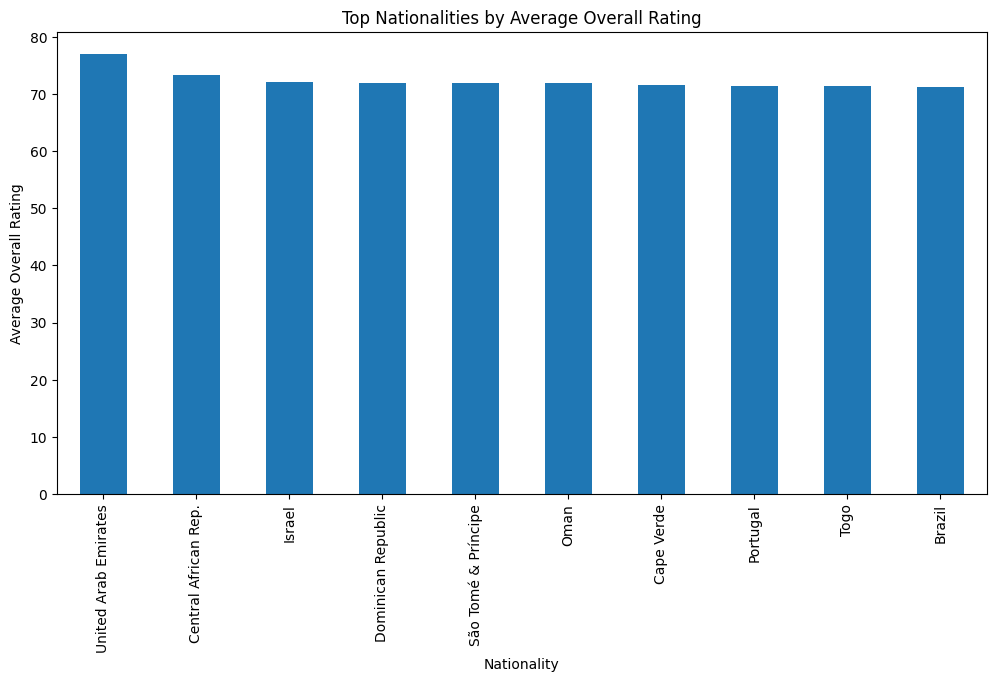

Text(0.5, 1.0, 'Correlation Matrix of Numeric Features')

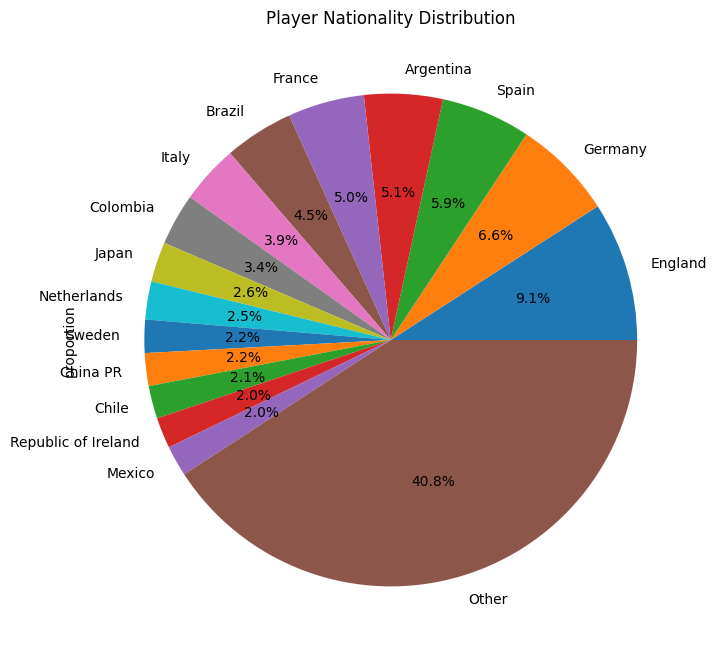

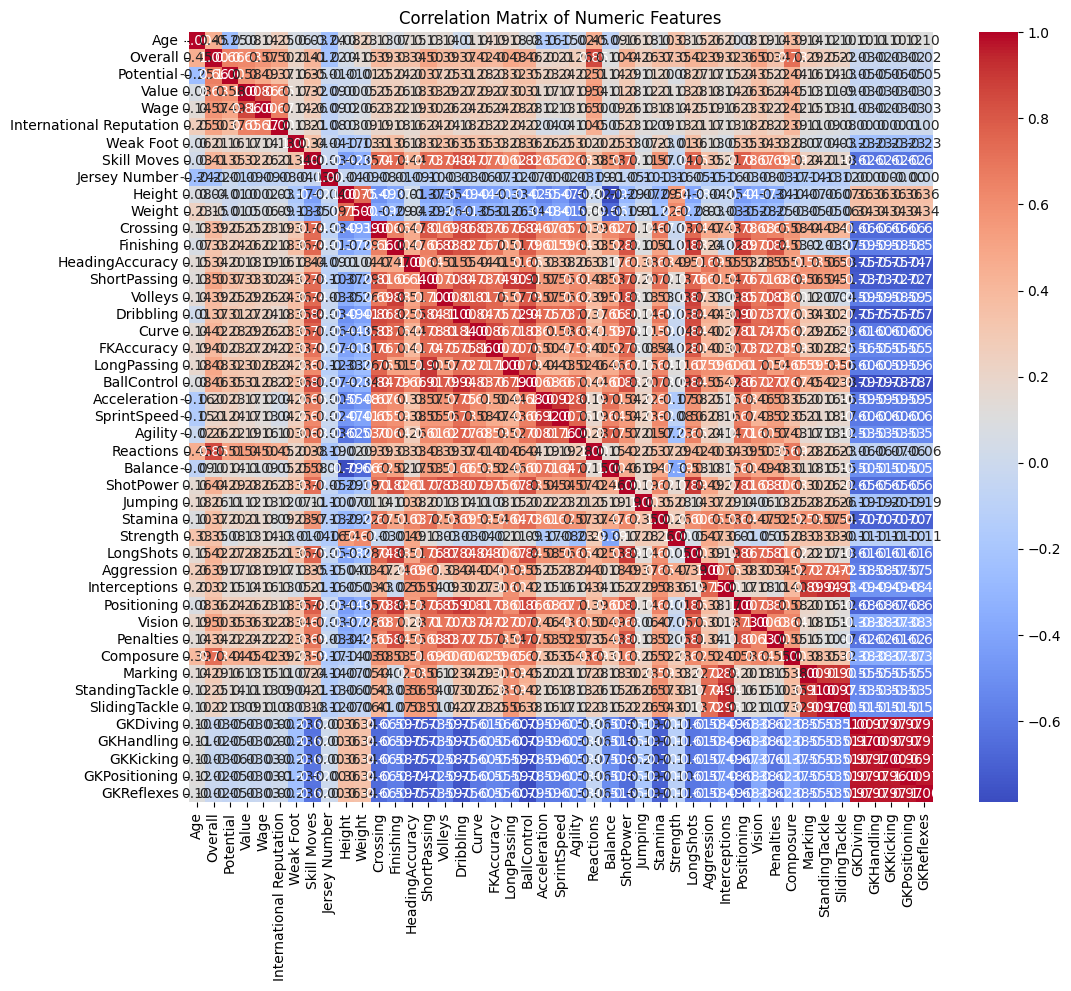

In [28]:
#stats
print("total number of players:", len(players))
print("number of unique clubs:", players['Club'].nunique())
print("number of unique nationalities:", players['Nationality'].nunique())
avg_wage = players.groupby("Club")["Wage"].mean().sort_values(ascending=False)
print("club with highest average wage:\n", avg_wage)
top_nationalities = players.groupby("Nationality")["Overall"].mean().sort_values(ascending=False).head(10)
top_nationalities.plot(kind='bar', figsize=(12,6), title="Top Nationalities by Average Overall Rating")
plt.ylabel("Average Overall Rating")
plt.show()
count = players['Nationality'].value_counts(normalize=True)*100
major = count[count > 2]
minor = count[count <= 2]
pie_data = major
pie_data['Other'] = minor.sum()
pie_data.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8), title="Player Nationality Distribution")
correlation_matrix = players[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")

To build my recommendation model, I’ll first need to make all my categorical features into numerics. I previously defined my categorical columns, so I turned them into dummies. Since there are many nationalities and clubs present in the dataset, I’m going to have to add some weights so that these features don’t make the dataset imbalanced. I’ll use k-Nearest Neighbor with the cosine distance, as it is a very common model for this kind of system. KNN is a simple, fast, and direct way of finding similarity between values. For my purposes, I want to find the 5 most similar players to a player.

In [29]:
cata = players[categorical_cols].copy()
cata.drop(columns=['Name'], inplace=True)

dummies = pd.get_dummies(cata, drop_first=True)

nat_cols = dummies.filter(like="Nationality_").columns
dummies[nat_cols] = dummies[nat_cols] * 0.3

club_cols = dummies.filter(like="Club_").columns
dummies[club_cols] = dummies[club_cols] * 0.4

X = pd.concat([scaled_df, dummies], axis=1)

In [30]:
nn = NearestNeighbors(n_neighbors=6, algorithm='auto', metric='cosine')
nn.fit(X)

,n_neighbors,6
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


My recommendation function takes in the name of a player and the number of similar players (by default 5). It will first check if the name is in the database, then it stores the row of that player’s entry. Then KNN is trained to find the k+1 most similar players (the first one is always the one being asked). We remove the first player and finally create a dataframe of the most similar players.

In [35]:
def Player_rec(name, k=5):
    if name not in players['Name'].values:
        return f"player {name} not found"
    idx = players[players['Name'] == name].index[0]
    distances, indices = nn.kneighbors(X.iloc[[idx]], n_neighbors=k+1)
    
    rec_indices = indices.flatten()[1:]
    rec_distances = distances.flatten()[1:]

    recommendations = players.iloc[rec_indices].copy()
    recommendations["distance"] = rec_distances

    return recommendations[["Name", "Club", "Wage", "Value", "Overall", "distance"]]

print("player reccomendations for 'Lionel Messi':")
recommendations = Player_rec("L. Messi", k=5)
print(recommendations)

player reccomendations for 'Lionel Messi':
            Name               Club      Wage       Value  Overall  distance
5      E. Hazard            Chelsea  340000.0  93000000.0       91  0.024290
32      Coutinho       FC Barcelona  340000.0  69500000.0       88  0.025533
7      L. Suárez       FC Barcelona  455000.0  80000000.0       91  0.026565
28  J. Rodríguez  FC Bayern München  315000.0  69500000.0       88  0.026918
6      L. Modrić        Real Madrid  420000.0  67000000.0       91  0.028842


But what if you want more specific recommendations? Here I made a second functions that is a little more in depth in what you can recommend. From the perspective of a manager, you would want to find an alternative to a greate player but maybe with a lower wage, greater overall, or maybe just a shorter height. This function is based on the previous recommendation function, but it will ask for a feature, and weather you want to be recommended a player with greater or lesser of that feature. For the feature to be comparable, it has to be a numerical feature rather than a catagorical. Then it follows the same step as the previous function, but if finds the max value of that feature and creates a score that uses the players feature as a baseline. Then its a matter of whether the sign flips the sorting order of the list.

In [36]:
def Player_rec_plus(name, feature, sign="+", k=5):
    if name not in players['Name'].values:
        return f"player: {name} not found"
    if feature not in players.columns:
        return f"feature: {feature} not found"
    if feature not in numeric_cols:
        return f"feature: {feature} must be a numerical value"
    if sign not in ["+", "-"]:
        return f"sign: {sign} must be '+' or '-'"
    
    idx = players[players['Name'] == name].index[0]
    distances, indices = nn.kneighbors(X.iloc[[idx]], n_neighbors=k+1)
    rec_indices = indices.flatten()[1:]
    rec_distances = distances.flatten()[1:]

    recommendations = players.iloc[rec_indices].copy()
    recommendations["distance"] = rec_distances
    
    max_value = recommendations[feature].max()
    recommendations["rec_plus"] = (recommendations[feature] / max_value)
    recommendations["rec_score"] = .7 * recommendations["distance"] + .3 * recommendations["rec_plus"]

    return recommendations.sort_values(by="rec_score", ascending=(sign=="-"))[["Name", "Club", feature]].head(k)


print("player reccomendations for 'Lionel Messi':")
recommendations = Player_rec_plus("L. Messi", "Hair", "-", k=5)
print(recommendations)

print("player reccomendations for 'Lionel Messi':")
recommendations = Player_rec_plus("L. Messi", "Overall", "?", k=5)
print(recommendations)

print("player reccomendations for 'Lionel Messi':")
recommendations = Player_rec_plus("L. Messi", "Club", "-", k=5)
print(recommendations)

print("player reccomendations for 'Lionel Messi':")
recommendations = Player_rec_plus("L. Messi", "Overall", "-", k=5)
print(recommendations)

player reccomendations for 'Lionel Messi':
feature: Hair not found
player reccomendations for 'Lionel Messi':
sign: ? must be '+' or '-'
player reccomendations for 'Lionel Messi':
feature: Club must be a numerical value
player reccomendations for 'Lionel Messi':
            Name               Club  Overall
32      Coutinho       FC Barcelona       88
28  J. Rodríguez  FC Bayern München       88
5      E. Hazard            Chelsea       91
7      L. Suárez       FC Barcelona       91
6      L. Modrić        Real Madrid       91



I want to find out whether the overall score forms clusters. First, I’ll create a random sample of 500 players, retrieve their row indices, and convert the subset into arrays. Then I’ll reduce some unnecessary dimensions and finally create a dataframe suitable for 2D visualization.

In [37]:
sample = players.sample(n=500, random_state=RANDOM_SEED)
sample_indeces = sample.index.tolist()
X_sample = X.iloc[sample_indeces].to_numpy()

pca = PCA(n_components=2, random_state=RANDOM_SEED)
x_pca = pca.fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, max_iter=3000)
x_tsne = tsne.fit_transform(X_sample)

plot_df = pd.DataFrame(
    {
        "x": x_tsne[:,0],
        "y": x_tsne[:,1],
        "Overall": sample["Overall"].values,
        "Name": sample["Name"].values
    }
)


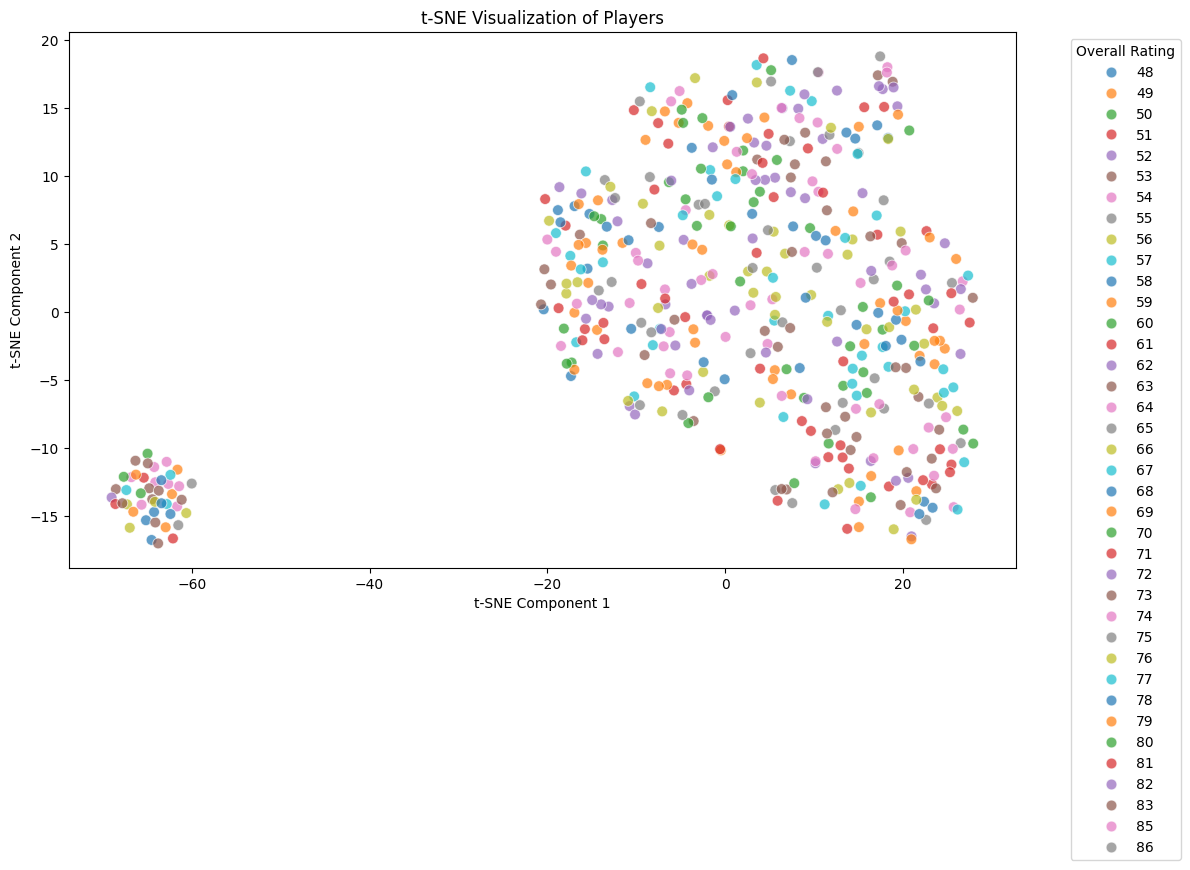

In [38]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=plot_df, x="x", y="y", hue="Overall", palette="tab10", s=60, alpha=0.7)
plt.title("t-SNE Visualization of Players")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Overall Rating", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()